# Aluminum solve using Tableau method

use the same constants as used in PHREEQC method

In [1]:
% setup environment
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
last_slash_pos = rindex(rootpath, "/");
rootpath=rootpath(1:last_slash_pos);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% clear data and number format
clear; format short e
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
graphics_toolkit ("plotly"); 
%graphics_toolkit("gnuplot")

In [2]:
% define equilibrium problem

AlT=5e-5;  pH=2:0.2:12; pe=20.75-pH; T=25; show=0;

In [3]:
% define the tableau as a function (mfile)

function [Al,AlOH3s,Al13,AlOH4,MASSERR]=Altableau(pH,pe,T,flag1,flag2,flag3,flag4,flag5)

% input tableau.  change this part % ----------------------------------------------

Tableau=[...
%H      e        Al             logK                                phase    species1 
1       0        0               0                                   0    {'H'}
0       1        0               0                                   0    {'e'}
0       0        1               0                                   0    {'Al'}
-1      0        0               -13.9951                            0    {'OH'}
-2      0        1               -10.5945                            0    {'AlOH2'}
-1      0        1               -4.9571                             0    {'AlOH'}
-1      0        1               -4.9571                             0    {'AlOH'}
-4      0        1               -22.7                               0    {'AlOH4'}
-2      0        2               -7.7902                             0    {'Al2OH2'}
-4      0        3               -13.8803                            0    {'Al3OH4'}
-32     0        13              -98.73                              0    {'Al13'}
%solids
-3       0       1               -7.7560                             1    {'AlOH3s'}
];

% end of tableau.  ------------------ % ----------------------------------------------

[KSOLID,ASOLID,SOLIDNAMES,KSOLUTION,ASOLUTION,SOLUTIONNAMES]=processtableau(Tableau,pH,pe);

[SPECIESCONCS,SPECIATIONNAMES,MASSERR,X]=returnspeciationRE(KSOLID,ASOLID,SOLIDNAMES,KSOLUTION,ASOLUTION,SOLUTIONNAMES,T,flag1,flag2,flag3,flag4,flag5);

for k=1:size(SPECIESCONCS,1)
      txt=[SPECIATIONNAMES(k,:),'=SPECIESCONCS(k);'];
      eval(txt)
end

end

# flag 4 

needs to be set to 1 so the answer is iterated towards using more and more complete tableau.  with a flag 4 of 1 

In [4]:
% MODEL USING TABLEAU (different gradients or log versus linear variables)
%graphics_toolkit("notebook")
%model with just inorganic speciation
%geochemical model
% input the constants and solution chemistry

flag1=2; %flag1 for concentration based search vector (1) or for log based search vector (2).
flag2=1; %flag2 for numerical derivatives (2) or analtyical derivatives (1)
flag3=0; % flag3 1 for show warnings. 0 no warnings
flag4=1; %if=1 solve tableau one line at a time to get a good initial guess (no solids). really challenging probs only
flag5=0; %if=1 use stored initial guess for including solids

TOTALS=[AlT];
TOTALS(TOTALS==0)=1e-16; % get rid of zero values, b/c div by zero error

for i=1:length(pH)
[Al(i),AlOH3s(i),Al13(i),AlOH4(i),MASSERR(i)]=Altableau(pH(i),pe(i),TOTALS',flag1,flag2,flag3,flag4,flag5);
end



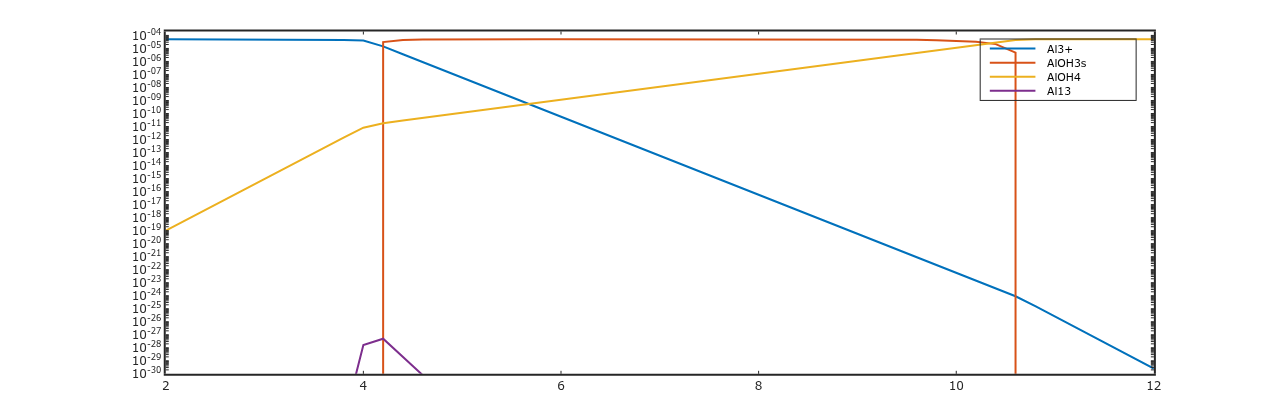

In [5]:
semilogy(pH,Al,'linewidth',2,pH,AlOH3s,'linewidth',2,pH,AlOH4,'linewidth',2, ...
pH,Al13,'linewidth',2)
 set(gca,'linewidth',2,'fontsize',12)
legend('Al3+','AlOH3s','AlOH4','Al13')
axis([2 12 1e-30 2e-4])

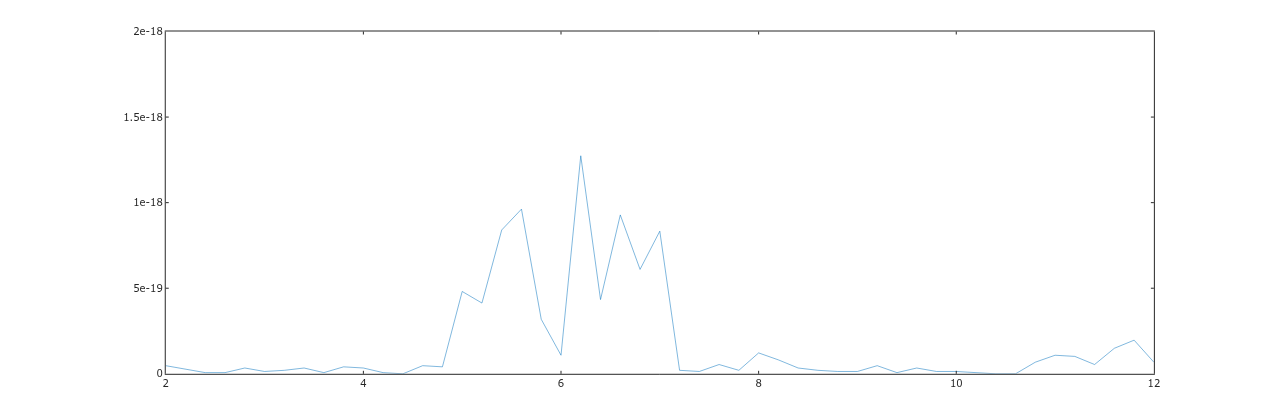

fatal: caught signal Aborted -- stopping myself...

In [6]:
plot(pH,MASSERR)